# Time Series

In [2]:
import pandas as pd

In [3]:
# Read in data 
URL = 'https://raw.githubusercontent.com/carmengg/eds-220-book/main/data/boulder_colorado_2013_hourly_precipitation.csv'
precip = pd.read_csv(URL)

precip.head()

,STATION,STATION_NAME,DATE,HPCP,Measurement Flag,Quality Flag
0,COOP:055881,NEDERLAND 5 NNW CO US,20000101 00:00,999.99,],
1,COOP:055881,NEDERLAND 5 NNW CO US,20000101 01:00,0.00,g,
2,COOP:055881,NEDERLAND 5 NNW CO US,20000102 20:00,0.00,,q
3,COOP:055881,NEDERLAND 5 NNW CO US,20000103 01:00,0.00,,q
4,COOP:055881,NEDERLAND 5 NNW CO US,20000103 05:00,0.00,,q


NA values are 999.99 in this dataset

In [4]:
# Read in csv but indicate NA values
precip = pd.read_csv(URL, na_values=999.99)
precip.head()

,STATION,STATION_NAME,DATE,HPCP,Measurement Flag,Quality Flag
0,COOP:055881,NEDERLAND 5 NNW CO US,20000101 00:00,NaN,],
1,COOP:055881,NEDERLAND 5 NNW CO US,20000101 01:00,0.0,g,
2,COOP:055881,NEDERLAND 5 NNW CO US,20000102 20:00,0.0,,q
3,COOP:055881,NEDERLAND 5 NNW CO US,20000103 01:00,0.0,,q
4,COOP:055881,NEDERLAND 5 NNW CO US,20000103 05:00,0.0,,q


<Axes: >

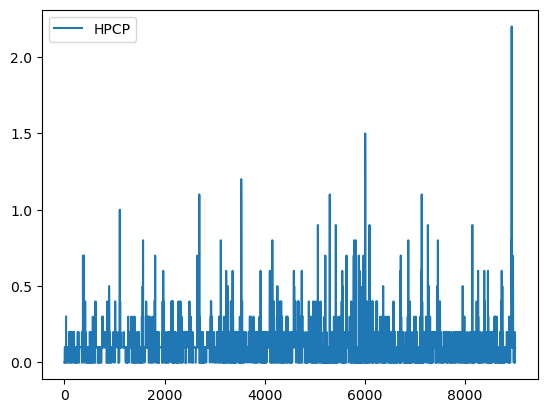

In [5]:
precip.plot()

In [6]:
precip.dtypes

STATION              object
STATION_NAME         object
DATE                 object
HPCP                float64
Measurement Flag     object
Quality Flag         object
dtype: object

DATE column is currently object type

In [7]:
# Convert to datetime
precip.DATE = pd.to_datetime(precip.DATE)

In [8]:
# Check that DATE is now datetime type
precip.dtypes

STATION                     object
STATION_NAME                object
DATE                datetime64[ns]
HPCP                       float64
Measurement Flag            object
Quality Flag                object
dtype: object

<Axes: xlabel='DATE'>

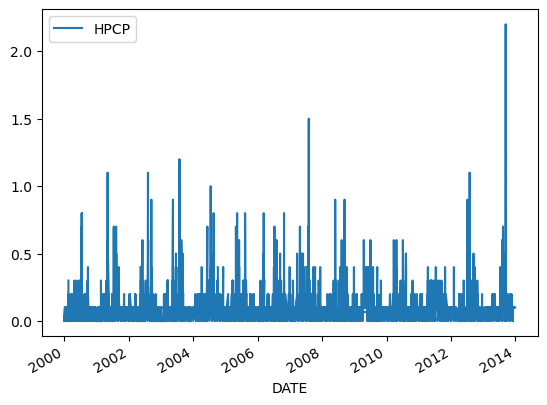

In [9]:
precip.plot(x = 'DATE', y = 'HPCP')

In [10]:
# Set index as date for subsetting and resampling
precip = precip.set_index('DATE')

In [11]:
precip.head()

,STATION,STATION_NAME,HPCP,Measurement Flag,Quality Flag
DATE,,,,,
2000-01-01 00:00:00,COOP:055881,NEDERLAND 5 NNW CO US,NaN,],
2000-01-01 01:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.0,g,
2000-01-02 20:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.0,,q
2000-01-03 01:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.0,,q
2000-01-03 05:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.0,,q


**We can also parse dates and set index directly from read_csv()**

`df = pd.read_csv(file, index_col=['date_column'], parse_dates=['date_column'])`

In [12]:
precip = pd.read_csv(URL,
                     na_values=999.99,
                     index_col=['DATE'],
                     parse_dates=['DATE'])

In [13]:
precip.head()

,STATION,STATION_NAME,HPCP,Measurement Flag,Quality Flag
DATE,,,,,
2000-01-01 00:00:00,COOP:055881,NEDERLAND 5 NNW CO US,NaN,],
2000-01-01 01:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.0,g,
2000-01-02 20:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.0,,q
2000-01-03 01:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.0,,q
2000-01-03 05:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.0,,q


## Subsetting by date

In [14]:
# Subset to dates: April 2013
precip.loc['2013-04']

,STATION,STATION_NAME,HPCP,Measurement Flag,Quality Flag
DATE,,,,,
2013-04-01 01:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.0,g,
2013-04-01 16:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.1,,
2013-04-02 13:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.1,,
2013-04-02 16:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.1,,
2013-04-02 17:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.1,,
...,...,...,...,...,...
2013-04-23 04:00:00,COOP:050843,BOULDER 2 CO US,0.1,,
2013-04-23 07:00:00,COOP:050843,BOULDER 2 CO US,0.1,,
2013-04-30 21:00:00,COOP:050843,BOULDER 2 CO US,0.1,,


In [15]:
# Subset to dates: 2015
precip.loc['2010']

,STATION,STATION_NAME,HPCP,Measurement Flag,Quality Flag
DATE,,,,,
2010-01-01 01:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.0,g,
2010-01-02 13:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.1,,
2010-01-06 04:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.1,,
2010-01-06 08:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.1,,
2010-01-06 17:00:00,COOP:055881,NEDERLAND 5 NNW CO US,0.1,,
...,...,...,...,...,...
2010-12-18 12:00:00,COOP:050843,BOULDER 2 CO US,0.1,,
2010-12-23 11:00:00,COOP:050843,BOULDER 2 CO US,0.1,,
2010-12-30 11:00:00,COOP:050843,BOULDER 2 CO US,0.1,,


<Axes: xlabel='DATE'>

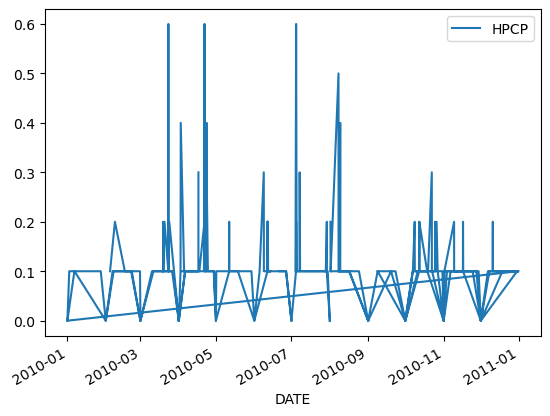

In [16]:
precip.loc['2010'].plot()

## Resampling

Converting a timeseries from one frequency to another, e.g. monthly to yearly / weekly to daily.

`df.resample(new_frequency).aggregator_function()`

In [17]:
# Resample 2013 hourly data to daily frequency
# Total daily precipitation in 2013
daily_precip_2013 = precip.loc['2013'].resample('D').sum() # 'Groupedby day' & sum up all hourly data

# Rename HPCP column to daily
daily_precip_2013 = daily_precip_2013.rename(columns={'HPCP': 'daily_precip'})
daily_precip_2013.head(3)

,STATION,STATION_NAME,daily_precip,Measurement Flag,Quality Flag
DATE,,,,,
2013-01-01,COOP:050183COOP:055881COOP:050183COOP:055121CO...,ALLENSPARK 2 SE CO USNEDERLAND 5 NNW CO USALLE...,0.0,]g[gg,
2013-01-02,0,0,0.0,0,0
2013-01-03,0,0,0.0,0,0


<Axes: title={'center': 'Precipitation: Boulder, CO, 2013'}, xlabel='Date', ylabel='Daily Precipitation (in)'>

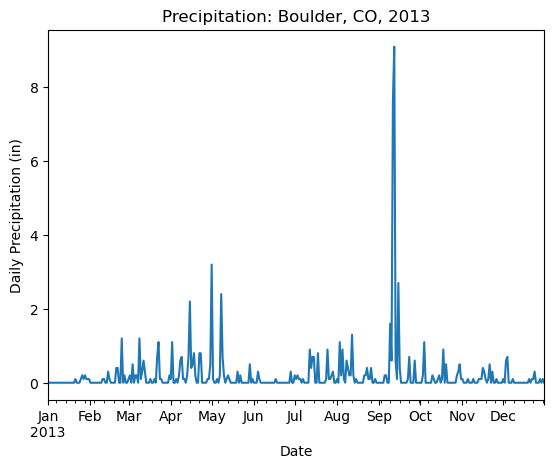

In [18]:
daily_precip_2013.plot(xlabel="Date", ylabel="Daily Precipitation (in)", legend=False, title="Precipitation: Boulder, CO, 2013")